In [31]:
import rasterio
from rasterio import features
from rasterio.windows import Window
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from sklearn.ensemble import RandomForestClassifier

#### Config

In [35]:
# Data paths
image_fp = '../data/raw/orthomosaics/2025-07-12_norte-1_orthomosaic_clipped.tif'
roi_fp = '../data/raw/vectors/SDH1_rois_v2.gpkg'

# Clipping window
col_off, row_off = 3200, 2000   # offset desde esq sup izq (X, Y)
width, height = 1200, 1200      # tamaño del cuadro a extraer
window = Window(col_off, row_off, width, height)

# Index of bands to use
bands_list = [1, 2, 3, 4, 5]

# Field name with classes data
class_field = 'layer'

# Classes dictionary
class_map = {
    'bare': 1,
    'veg': 2,
    'salt': 3
}

#### Functions

In [33]:
# funcion para estirar valores para visualizacion
def get_clean_stretch(band, mask, p_low=2, p_high=98):
    valid_pixels = band[mask]

    if valid_pixels.size == 0:
        return np.zeros_like(band)
    
    low, high = np.percentile(valid_pixels, (p_low, p_high))

    stretched = np.clip(band, low, high)

    if high - low == 0:
        return np.zeros_like(band)
        
    return (stretched - low) / (high - low)

#### Data preparation

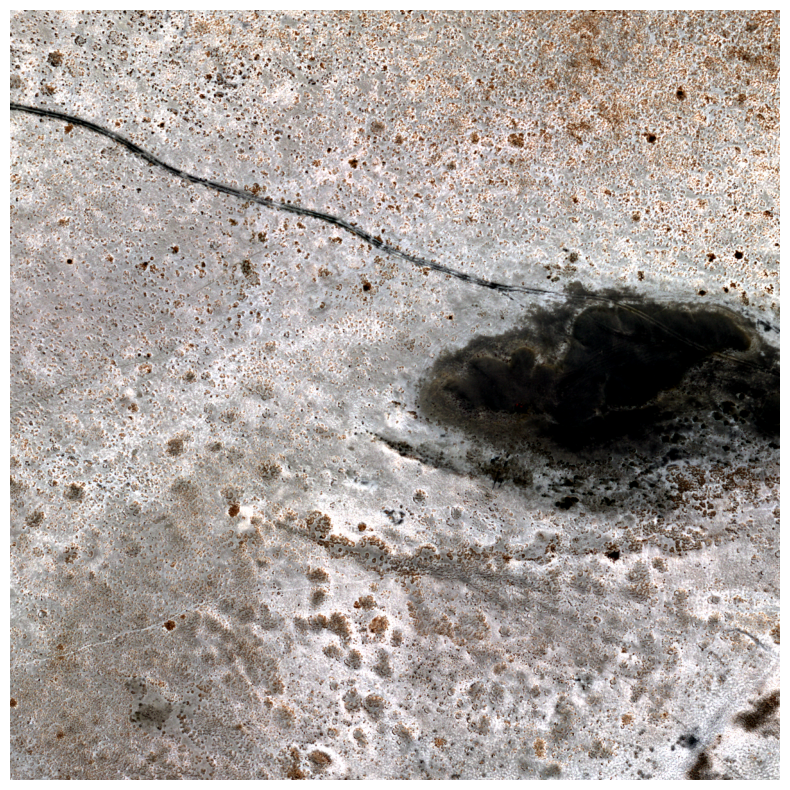

In [36]:
# abrir archivo y recortar a una ventana
with rasterio.open(image_fp) as src:

    # lectura de bandas especificadas y clipeo a ventana
    subset = src.read(bands_list, window=window).astype('float32')

    # Obtener las dimensiones reales del array
    _, actual_height, actual_width = subset.shape

    # manejo de nodata
    if src.nodata is not None:
        mask = ~np.all(subset == src.nodata, axis=0)
    else:
        mask = ~np.all(subset == 0, axis=0)

    # metadatos del recorte
    subset_meta = src.profile.copy()
    subset_meta.update({
        'height': actual_height,
        'width': actual_width,
        'transform': src.window_transform(window),
        'count': len(bands_list)
    })

# aplicar estiramiento
list_stretched = []
for i in range(len(bands_list)):
    band_st = get_clean_stretch(subset[i], mask)
    list_stretched.append(band_st)

# componer imagen
rgb = np.dstack((list_stretched[2], list_stretched[1], list_stretched[0]))
rgb[~mask] = 1  # Los píxeles fuera de la máscara se verán blancos

# visualization
plt.figure(figsize=(10, 10))
plt.imshow(rgb)
plt.axis('off')
plt.show()

In [37]:
# Carga de poligonos de entrenamiento
gdf = gpd.read_file(roi_fp)

# Asegurar la consistencia del CRS antes de rasterizar
crs_raster = subset_meta['crs']
if gdf.crs is None:
    print("El GeoPackage no tenía CRS. Asignando el CRS del raster original.")
    gdf.set_crs(crs_raster, inplace=True)
elif gdf.crs != crs_raster:
    print(f"Reproyectando vectores de {gdf.crs} al CRS del raster {crs_raster}")
    gdf = gdf.to_crs(crs_raster)

In [38]:
# Crear una nueva columna numérica basada en el mapeo
gdf['class_id'] = gdf[class_field].map(class_map)

# Validar que no haya valores nulos
if gdf['class_id'].isnull().any():
    print("¡Advertencia! Hay clases en el GPKG que no están en tu diccionario class_map.")
    print(gdf[gdf['class_id'].isnull()][class_field].unique())

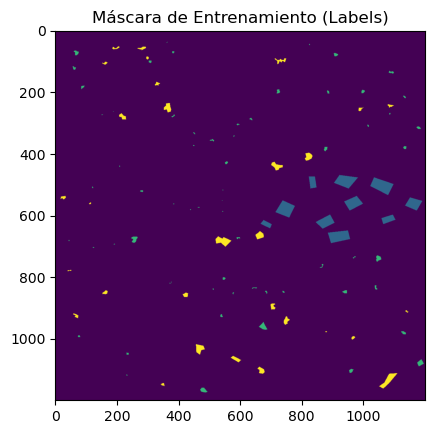

In [39]:
# Crear una matriz vacía del mismo tamaño que el recorte (alto, ancho)
out_shape = (subset_meta['height'], subset_meta['width'])

# Generar la máscara de entrenamiento
train_mask = features.rasterize(
    [(shape, label) for shape, label in zip(gdf.geometry, gdf['class_id'])],
    out_shape=out_shape,
    transform=subset_meta['transform'],
    fill=0,
    dtype='uint8'
)

plt.imshow(train_mask, cmap='viridis')
plt.title("Máscara de Entrenamiento (Labels)")
plt.show()

#### Random forest classification

In [40]:
# 1. Aplanamos las 5 bandas: de (5, alto, ancho) a (n_pixeles, 5)
# Usamos el 'full_subset' que contenía las 5 bandas originales
X_all = subset.reshape(len(bands_list), -1).T

# 2. Aplanamos la máscara de etiquetas
y_all = train_mask.ravel()

# 3. Solo nos interesan los píxeles donde pusimos una etiqueta (y > 0)
# y que no sean NoData (usando la máscara 'mask' que definimos antes)
train_indices = (y_all > 0) & (mask.ravel())

X_train = X_all[train_indices]
y_train = y_all[train_indices]

print(f"Entrenando con {X_train.shape[0]} píxeles de muestra.")

Entrenando con 26380 píxeles de muestra.


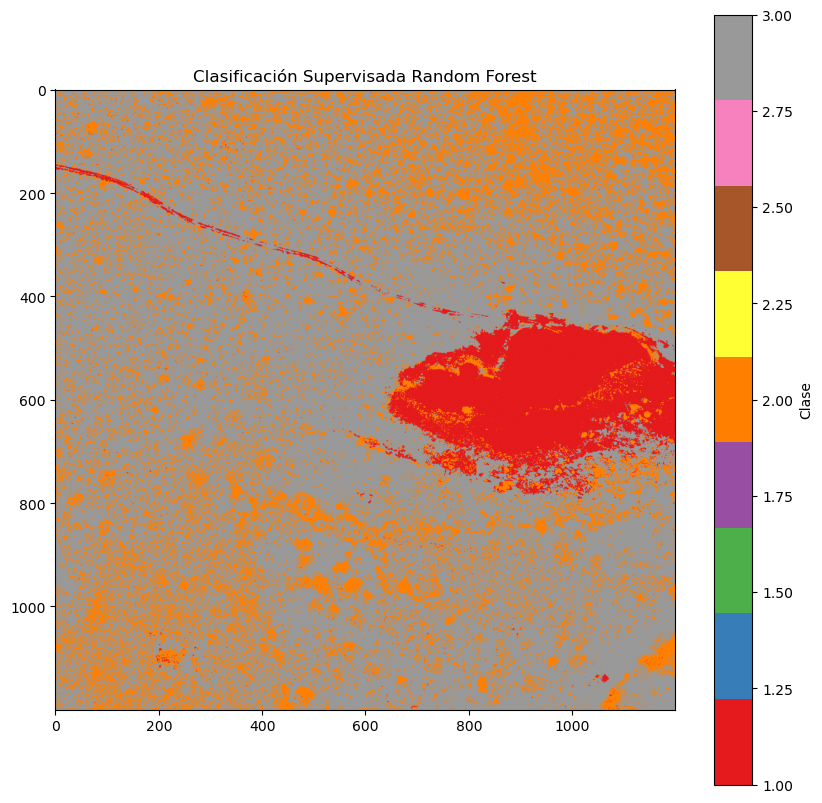

In [41]:
# Inicializamos el clasificador
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)

# Entrenamos
rf.fit(X_train, y_train)

# Clasificamos todo el recorte (todos los píxeles con datos)
# Solo predecimos donde mask es True para ahorrar tiempo
X_to_predict = X_all[mask.ravel()]
prediction_flat = rf.predict(X_to_predict)

# Reconstruimos la imagen clasificada
classification = np.zeros(y_all.shape, dtype='uint8')
classification[mask.ravel()] = prediction_flat
classification = classification.reshape(out_shape)

# Visualización final
plt.figure(figsize=(10,10))
plt.imshow(classification, cmap='Set1')
plt.title("Clasificación Supervisada Random Forest")
plt.colorbar(label="Clase")
plt.show()

#### Data exportation

In [42]:
# Definir la ruta de salida
output_path = '../outputs/classification/SDH1_classification.tif'

# Preparar los metadatos para el archivo de salida
# Tomamos los metadatos del subset y los ajustamos para una sola banda de clasificación
out_meta = subset_meta.copy()
out_meta.update({
    "driver": "GTiff",
    "count": 1,          # Una sola banda (la clasificación)
    "dtype": "uint8",    # Tipo de dato entero para las clases
    "nodata": 0,         # Definimos 0 como valor para áreas sin datos
    "compress": "lzw"    # Compresión sin pérdida para ahorrar espacio
})

# Guardar el archivo en disco
with rasterio.open(output_path, "w", **out_meta) as dest:
    # Escribimos la matriz de clasificación (asegurándonos de que sea uint8)
    dest.write(classification.astype('uint8'), 1)
    
    # Opcional: Añadir nombres a las clases como etiquetas internas (metadatos)
    dest.update_tags(1, 
        class_1="bare", 
        class_2="veg", 
        class_3="salt"
    )

print(f"Clasificación exportada exitosamente en: {output_path}")

Clasificación exportada exitosamente en: ../outputs/classification/SDH1_classification.tif


#### NDVI calculation

Calculating NDVI...
Extracting spatial samples...
Sample extraction complete. DataFrame shape: (1500, 8)
Generating visualizations...


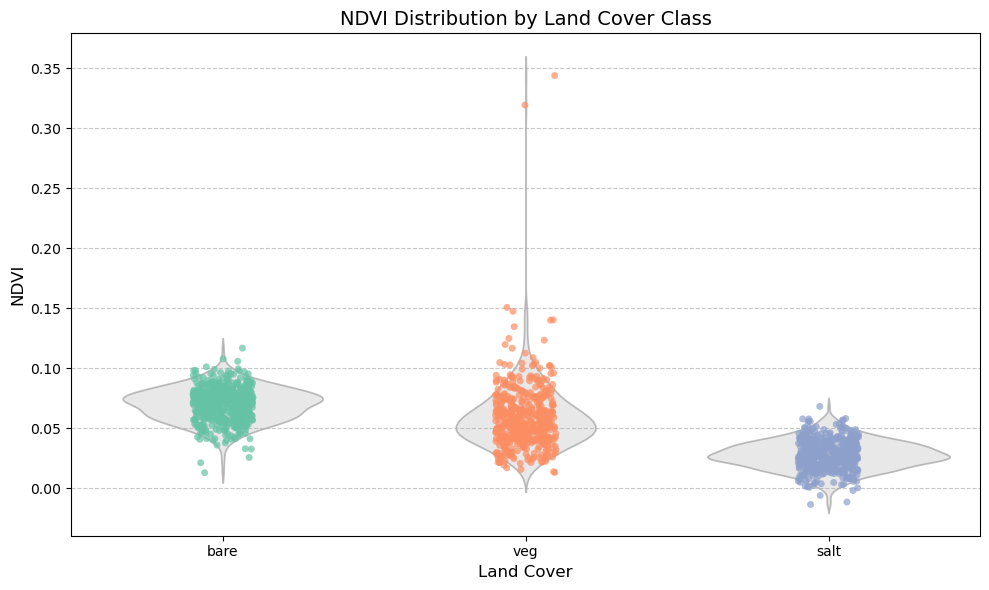

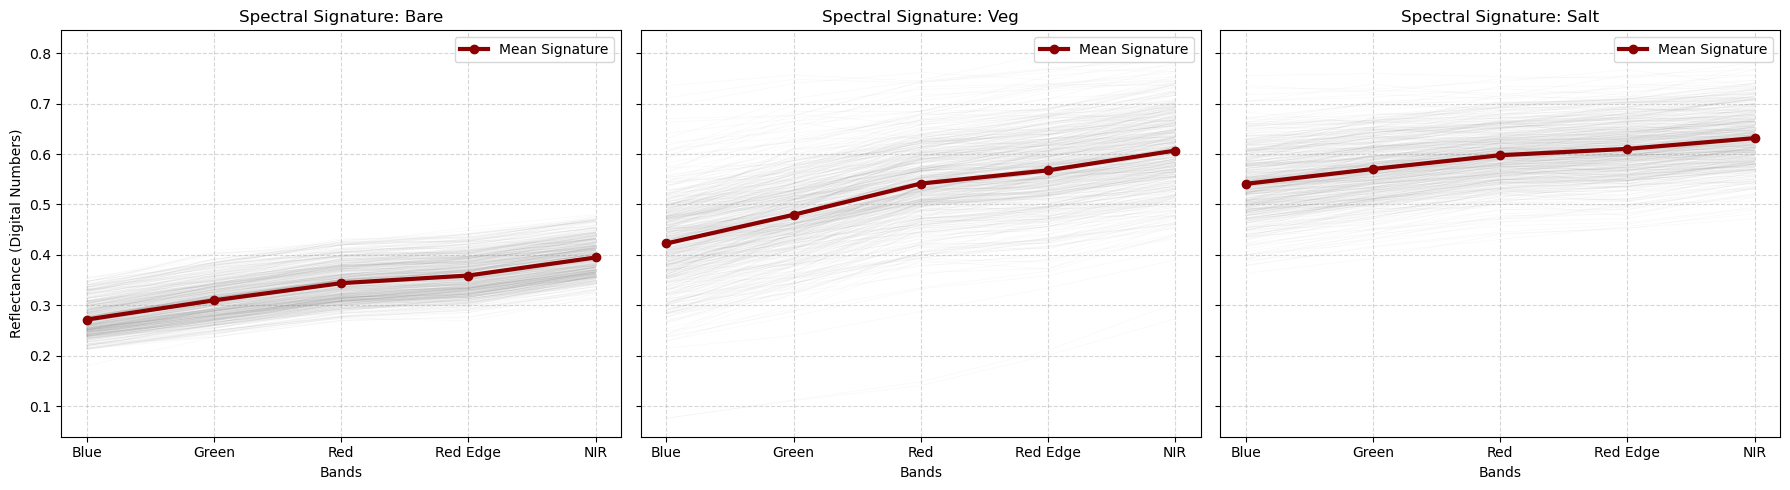

In [43]:
import pandas as pd
import seaborn as sns

# ==========================================
# 1. DATA PREPARATION (NDVI CALCULATION)
# ==========================================

def calculate_ndvi(red_array, nir_array, valid_mask):
    """
    Calculates the Normalized Difference Vegetation Index (NDVI).
    Handles NoData by assigning NaN to invalid pixels and avoids division by zero.
    """
    # Initialize an array with NaNs
    ndvi = np.full(red_array.shape, np.nan, dtype=np.float32)
    
    # Create a mask to prevent division by zero
    denominator = nir_array + red_array
    calc_mask = valid_mask & (denominator != 0)
    
    # Calculate NDVI only where valid
    ndvi[calc_mask] = (nir_array[calc_mask] - red_array[calc_mask]) / denominator[calc_mask]
    
    return ndvi

# ==========================================
# 2. SPATIAL SAMPLING WORKFLOW
# ==========================================

def sample_raster_classes(class_array, ms_array, ndvi_array, valid_mask, n_points=500):
    """
    Generates random point samples for each detected class.
    Extracts class ID, NDVI, and reflectance values for the 5 original bands.
    """
    records = []
    point_id = 0
    
    # Find unique classes in the classification array (ignoring background 0)
    unique_classes = np.unique(class_array[valid_mask])
    unique_classes = [c for c in unique_classes if c > 0] 
    
    for class_val in unique_classes:
        # Get row and column indices of all pixels belonging to this class
        row_indices, col_indices = np.where((class_array == class_val) & valid_mask)
        
        # Handle cases where a class has fewer pixels than the requested n_points
        available_pixels = len(row_indices)
        n_samples = min(n_points, available_pixels)
        
        # Randomly select pixels without replacement
        random_choices = np.random.choice(available_pixels, n_samples, replace=False)
        
        for idx in random_choices:
            r = row_indices[idx]
            c = col_indices[idx]
            
            # Extract data for the selected pixel
            records.append({
                'punto_id': point_id,
                'clase': class_val,
                'ndvi': ndvi_array[r, c],
                'B1_Blue': ms_array[0, r, c],
                'B2_Green': ms_array[1, r, c],
                'B3_Red': ms_array[2, r, c],
                'B4_RedEdge': ms_array[3, r, c],
                'B5_NIR': ms_array[4, r, c]
            })
            point_id += 1
            
    return pd.DataFrame(records)

# ==========================================
# 3. VISUALIZATION
# ==========================================

def plot_ndvi_distribution(df_samples, reverse_mapping):
    """
    Creates a jitterplot (stripplot combined with violinplot) to show 
    the NDVI distribution grouped by land cover class.
    """
    # Add descriptive class names to the DataFrame for plotting
    df_plot = df_samples.copy()
    df_plot['class_name'] = df_plot['clase'].map(reverse_mapping)
    
    plt.figure(figsize=(10, 6))
    
    # Violinplot to show the probability density of the data
    sns.violinplot(
        data=df_plot, x='class_name', y='ndvi', 
        color='lightgray', inner=None, alpha=0.5
    )
    
    # Stripplot to overlay the actual sampled points
    sns.stripplot(
        data=df_plot, x='class_name', y='ndvi', 
        hue='class_name', palette='Set2', jitter=True, alpha=0.7
    )
    
    plt.title('NDVI Distribution by Land Cover Class', fontsize=14)
    plt.xlabel('Land Cover', fontsize=12)
    plt.ylabel('NDVI', fontsize=12)
    
    # Clean up layout
    plt.legend([],[], frameon=False) 
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_spectral_signatures(df_samples, reverse_mapping):
    """
    Generates spectral signature subplots (one per class).
    Plots all individual sampled signatures and superimposes the mean signature.
    """
    bands_cols = ['B1_Blue', 'B2_Green', 'B3_Red', 'B4_RedEdge', 'B5_NIR']
    band_names = ['Blue', 'Green', 'Red', 'Red Edge', 'NIR']
    
    unique_classes = df_samples['clase'].unique()
    n_classes = len(unique_classes)
    
    # Create subplots based on the number of classes
    fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 5), sharey=True)
    
    # Ensure axes is iterable even if there is only 1 class
    if n_classes == 1:
        axes = [axes]
        
    for ax, class_val in zip(axes, unique_classes):
        class_data = df_samples[df_samples['clase'] == class_val]
        reflectance_values = class_data[bands_cols].values
        
        class_name = reverse_mapping.get(class_val, "Unknown")
        
        # Plot individual pixel signatures (gray, high transparency)
        for row in reflectance_values:
            ax.plot(band_names, row, color='gray', alpha=0.05, linewidth=0.5)
            
        # Calculate and plot the mean spectral signature
        mean_signature = reflectance_values.mean(axis=0)
        ax.plot(
            band_names, mean_signature, 
            color='darkred', linewidth=3, marker='o', 
            label='Mean Signature'
        )
        
        ax.set_title(f'Spectral Signature: {class_name.capitalize()}', fontsize=12)
        ax.set_xlabel('Bands')
        if ax == axes[0]:
            ax.set_ylabel('Reflectance (Digital Numbers)')
            
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='upper right')
        
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. EXECUTION WORKFLOW
# ==========================================

# Map indices for Red (index 2) and NIR (index 4) based on your original subset
red_band = subset[2]
nir_band = subset[4]

# Step 1: Calculate NDVI
print("Calculating NDVI...")
ndvi_layer = calculate_ndvi(red_band, nir_band, mask)

# Step 2: Extract spatial samples (500 per class)
print("Extracting spatial samples...")
df_samples = sample_raster_classes(
    class_array=classification, 
    ms_array=subset, 
    ndvi_array=ndvi_layer, 
    valid_mask=mask, 
    n_points=500
)

print(f"Sample extraction complete. DataFrame shape: {df_samples.shape}")

# Create a reverse dictionary to map integer IDs back to class names for the plots
reverse_class_map = {v: k for k, v in class_map.items()}

# Step 3: Visualizations
print("Generating visualizations...")
plot_ndvi_distribution(df_samples, reverse_class_map)
plot_spectral_signatures(df_samples, reverse_class_map)

In [44]:
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ==========================================
# 5. STATISTICAL ANALYSIS (ANOVA & POST HOC)
# ==========================================

def analyze_ndvi_differences(df, alpha=0.05):
    """
    Performs a One-Way ANOVA test to check for significant differences in NDVI 
    across different land cover classes. If significant, runs a Tukey HSD post hoc test.
    """
    print("=== ANOVA Test ===")
    
    # Drop any potential NaNs in NDVI to avoid statistical errors
    df_clean = df.dropna(subset=['ndvi']).copy()
    
    # Group the NDVI values by class into a list of arrays
    unique_classes = df_clean['clase'].unique()
    ndvi_groups = [df_clean[df_clean['clase'] == cls]['ndvi'] for cls in unique_classes]

    # Perform One-Way ANOVA
    f_stat, p_value = stats.f_oneway(*ndvi_groups)
    
    print(f"F-statistic: {f_stat:.4f}")
    print(f"P-value:     {p_value:.4e}\n")
    
    # Check if the differences are statistically significant
    if p_value < alpha:
        print(f"Result: Significant differences exist between the classes (p < {alpha}).")
        print("\n=== Post Hoc Test (Tukey HSD) ===")
        
        # Map numeric class IDs to string names for a readable output table
        # (Assuming reverse_class_map was defined in the previous cell)
        df_clean['class_name'] = df_clean['clase'].map(reverse_class_map)
        
        # Run Tukey's HSD test to see exactly WHICH classes differ
        tukey_result = pairwise_tukeyhsd(
            endog=df_clean['ndvi'],   # Data
            groups=df_clean['class_name'], # Groups
            alpha=alpha               # Significance level
        )
        
        # Print the summary table
        print(tukey_result)
        
    else:
        print(f"Result: No significant differences found (p >= {alpha}).")
        print("Classes have statistically similar NDVI distributions. Post hoc test bypassed.")

# Execute the analysis
# Note: Ensure that 'scipy' and 'statsmodels' are installed in your environment
analyze_ndvi_differences(df_samples, alpha=0.05)

=== ANOVA Test ===
F-statistic: 624.0707
P-value:     0.0000e+00

Result: Significant differences exist between the classes (p < 0.05).

=== Post Hoc Test (Tukey HSD) ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  bare   salt  -0.0419   0.0 -0.0448  -0.039   True
  bare    veg   -0.011   0.0 -0.0139 -0.0081   True
  salt    veg   0.0309   0.0   0.028  0.0338   True
---------------------------------------------------


Hay diferencias significativas entre vegetación y sal y entre suelo desnudo y sal, mas no entre vegetación y suelo desnudo